# L4. Your On-Device Assistant

A day of photos, voice notes, and text notes land in one `EdgeShard`: the kind of day a phone or a pair of smart glasses captures. You build the recall yourself, then ask it your own questions and add your own memories, all offline.

## 1. A day's captures

In [1]:
import json
from collections import Counter

memories = json.load(open("./ro_shared_data/memories.json"))
counts = Counter(m["source_type"] for m in memories)
print(len(memories), "captures:",
      ", ".join(f"{v} {k}" for k, v in sorted(counts.items())))

42 captures: 17 photo, 20 text, 5 voice


In [2]:
import onnx_asr
from IPython.display import Audio
from helper import transcribe_notes

# Hear one voice note become text, on-device:
voice = [m for m in memories if m["source_type"] == "voice"]
clip = f"./ro_shared_data/audio/{voice[0]['audio_file']}"
asr = onnx_asr.load_model("whisper-base",
                          providers=["CPUExecutionProvider"])
print("Heard on-device:", asr.recognize(clip).strip())
del asr

# transcribe_notes repeats that recognize() for every voice note,
# then frees the model to make room for the embedding models.
transcribe_notes(memories, "./ro_shared_data/audio")
Audio(clip)

Heard on-device: Note to self, the ramen downtown was incredible, $14 and worth it. Sat right by the window.


## 2. The day at a glance

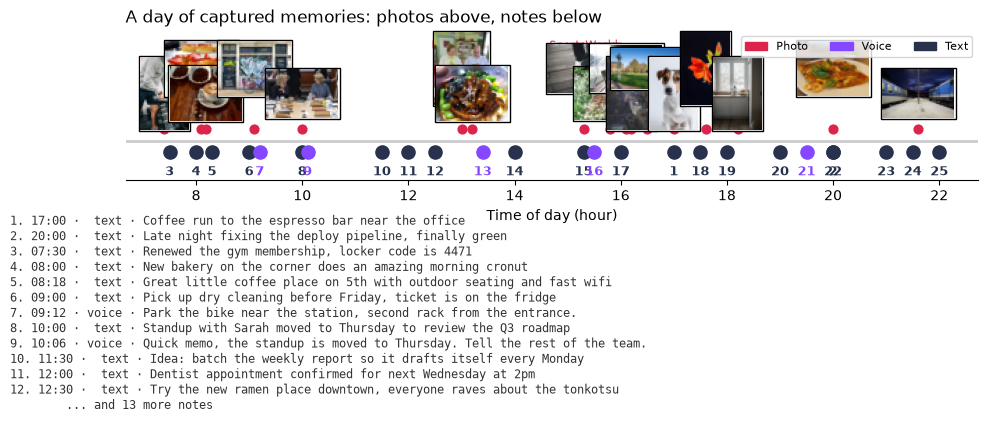

In [3]:
from helper import day_timeline
day_timeline(memories, "./ro_shared_data/images")

## 3. Set up the day's shard

In [4]:
from qdrant_edge import (
    EdgeShard, EdgeConfig, EdgeVectorParams, Distance,
)
from helper import fresh_start

SHARD_DIR = fresh_start("./day_shard")

config = EdgeConfig(
    vectors={
        "text": EdgeVectorParams(size=768, distance=Distance.Cosine),
        "image": EdgeVectorParams(size=512, distance=Distance.Cosine),
    }
)
shard = EdgeShard.create(SHARD_DIR, config)
print("Shard ready: text 768-d (Nomic), image 512-d (CLIP)")

Shard ready: text 768-d (Nomic), image 512-d (CLIP)


## 4. Store the day

In [5]:
from qdrant_edge import Point, UpdateOperation
from helper import embed_text

texts = [m for m in memories if m["source_type"] in ("text", "voice")]

note_texts = [m.get("note") or m["transcript"] for m in texts]
text_vectors = embed_text(note_texts)
shard.update(UpdateOperation.upsert_points([
    Point(id=m["id"], vector={"text": vector}, payload=m)
    for m, vector in zip(texts, text_vectors)
]))
print("Stored", len(texts), "text and voice memories")

Stored 25 text and voice memories


In [6]:
from helper import embed_image

photos = [m for m in memories if m["source_type"] == "photo"]

photo_paths = [f"./ro_shared_data/images/{m['file']}" for m in photos]
image_vectors = embed_image(photo_paths)
shard.update(UpdateOperation.upsert_points([
    Point(id=m["id"], vector={"image": vector}, payload=m)
    for m, vector in zip(photos, image_vectors)
]))
shard.optimize()
print("Total memories:", shard.info().points_count)

Total memories: 42


## 5. Inspect a stored point

In [7]:
from qdrant_edge import ScrollRequest

records, _ = shard.scroll(
    ScrollRequest(limit=1, with_payload=True, with_vector=True)
)
p = records[0]
vector = p.vector["text"]
print("id:", p.id)
print("text vector:", [round(x, 3) for x in vector[:6]],
      f"... {len(vector)} numbers")
print("payload:", p.payload)

id: 0
text vector: [-0.035, 0.027, -0.221, -0.011, 0.004, -0.014] ... 768 numbers
payload: {'id': 0, 'source_type': 'text', 'category': 'food', 'location': '5th St', 'timestamp': 1699949880, 'note': 'Great little coffee place on 5th with outdoor seating and fast wifi'}


## 6. How recall works

In [8]:
from qdrant_edge import Query, QueryRequest
from helper import embed_query, embed_query_clip, show_raw


def recall(question):
    text_vector = embed_query(question)
    image_vector = embed_query_clip(question)
    # fetch extra text hits so one lane cannot crowd out the other
    text_hits = shard.query(
        QueryRequest(
            query=Query.Nearest(text_vector, using="text"),
            limit=10,
            with_payload=True,
        )
    )
    image_hits = shard.query(
        QueryRequest(
            query=Query.Nearest(image_vector, using="image"),
            limit=1,
            with_payload=True,
        )
    )
    return {
        "Photos": image_hits,
        "Voice Notes": [h for h in text_hits
                        if h.payload.get("source_type") == "voice"][:3],
        "Text Notes": [h for h in text_hits
                       if h.payload.get("source_type") == "text"][:3],
    }


print("one question becomes two vectors:",
      len(embed_query("ramen")), "d Nomic for text ·",
      len(embed_query_clip("ramen")), "d CLIP for photos")

one question becomes two vectors: 768 d Nomic for text · 512 d CLIP for photos


## 7. Your turn: recall your day

Photos      0.247 id=28  Ramen-ya
Voice Notes 0.809 id=20  Ramen-ya
Voice Notes 0.442 id=23  Park the bike near the station, se
Voice Notes 0.428 id=22  Quick memo, the standup is moved t
Text Notes  0.786 id=8  Try the new ramen place downtown, 
Text Notes  0.513 id=0  Great little coffee place on 5th w
Text Notes  0.473 id=18  Coffee run to the espresso bar nea



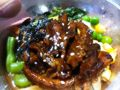

In [9]:
from helper import memory_inbox

# Change my_question and re-run. Try: "where did I park the bike",
# "gym locker code", "when is the dentist".
my_question = "the ramen place downtown"

hits = recall(my_question)
show_raw(hits)
memory_inbox(hits, "./ro_shared_data/images", min_score=0.6)

## 8. Add your own memory, then recall it

Photos      0.213 id=31  bicycle.jpg
Voice Notes 0.475 id=23  Park the bike near the station, se
Voice Notes 0.468 id=24  Just remember, we are low on coffe
Voice Notes 0.411 id=20  Ramen-ya
Text Notes  0.757 id=900  Left the spare key with the neighb
Text Notes  0.457 id=10  Renewed the gym membership, locker
Text Notes  0.442 id=12  Remember to call the landlord abou



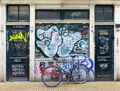

In [10]:
# Add your own memory, then ask for it. Change both together!
my_note = "Left the spare key with the neighbor in apartment 4B"
my_question = "where did I leave the spare key"

my_memory = {
    "id": 900, "source_type": "text", "category": "home",
    "location": "Home",
    "timestamp": max(m["timestamp"] for m in memories),
    "note": my_note,
}
shard.update(UpdateOperation.upsert_points([
    Point(id=my_memory["id"], vector={"text": embed_text([my_note])[0]},
          payload=my_memory),
]))
shard.optimize()

hits = recall(my_question)
show_raw(hits)
memory_inbox(hits, "./ro_shared_data/images", min_score=0.6)